In [1]:
import numpy as np
import matplotlib.pyplot as plt

from collections import namedtuple
from itertools import product

from matplotlib.patches import Polygon

import ipywidgets as widgets
from math import cos, sin, sqrt, pi

In [2]:
Polyhedron = namedtuple(typename = "Polyhedron", field_names = ('vertices', 'faces'))

In [3]:
def rotate_ox(a):
    return np.array([
        [1, 0, 0, 0],
        [0, cos(a), -sin(a), 0],
        [0, sin(a), cos(a), 0],
        [0, 0, 0, 1]
    ])

def rotate_oy(a):
    return np.array([
        [cos(a), 0, sin(a), 0],
        [0, 1, 0, 0],
        [-sin(a), 0, cos(a), 0],
        [0, 0, 0, 1]
    ])

def rotate_oz(a):
    return np.array([
        [cos(a), -sin(a), 0, 0],
        [sin(a), cos(a), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

def translate(tx, ty, tz):
    return np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
])

def perspective(p, q, r):
    return np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [p, q, r, 1]
])

def normalize_in_place(points):
    last_column = points[:, -1]
    points[:, :] = points / last_column[:, np.newaxis]

def normalize(points):
    last_column = points[:, -1]
    return points / last_column[:, np.newaxis]

In [4]:
def signed_square(vertices, face):
    p1, p2, p3 = vertices[face][0:3, (0, 1, 3)]
    return np.linalg.det(np.column_stack((p1, p2, p3)))

In [5]:
cube = Polyhedron(
    vertices = np.array([
    [0, 0, 0, 1], # 0
    [0, 1, 0, 1], # 1
    [1, 1, 0, 1], # 2
    [1, 0, 0, 1], # 3
    [0, 0, 1, 1], # 4
    [0, 1, 1, 1], # 5
    [1, 1, 1, 1], # 6
    [1, 0, 1, 1], # 7
]),

    faces = [
        [0, 4, 5, 1],
        [0, 3, 7, 4], 
        [3, 2, 6, 7],
        [2, 1, 5, 6],
        [0, 1, 2, 3],
        [6, 5, 4, 7],
    ]
)

In [6]:
vertices1 = normalize(cube.vertices @ rotate_oy(np.deg2rad(60)).T @ translate(0, -2, 0).T @ perspective(0, 0, -2/5).T)
vertices1

array([[ 0.        , -2.        ,  0.        ,  1.        ],
       [ 0.        , -1.        ,  0.        ,  1.        ],
       [ 0.37135786, -0.74271573, -0.64321069,  1.        ],
       [ 0.37135786, -1.48543145, -0.64321069,  1.        ],
       [ 1.08253175, -2.5       ,  0.625     ,  1.        ],
       [ 1.08253175, -1.25      ,  0.625     ,  1.        ],
       [ 1.19156777, -0.87228815, -0.31927962,  1.        ],
       [ 1.19156777, -1.7445763 , -0.31927962,  1.        ]])

In [7]:
vertices2 = normalize(cube.vertices @ rotate_oy(np.deg2rad(120)).T @ translate(0, 2, 0).T @ perspective(0, 0, -2/5).T)
vertices2

array([[ 0.        ,  2.        ,  0.        ,  1.        ],
       [ 0.        ,  3.        ,  0.        ,  1.        ],
       [-0.37135786,  2.22814718, -0.64321069,  1.        ],
       [-0.37135786,  1.48543145, -0.64321069,  1.        ],
       [ 0.72168784,  1.66666667, -0.41666667,  1.        ],
       [ 0.72168784,  2.5       , -0.41666667,  1.        ],
       [ 0.23669361,  1.93997691, -0.88335258,  1.        ],
       [ 0.23669361,  1.29331794, -0.88335258,  1.        ]])

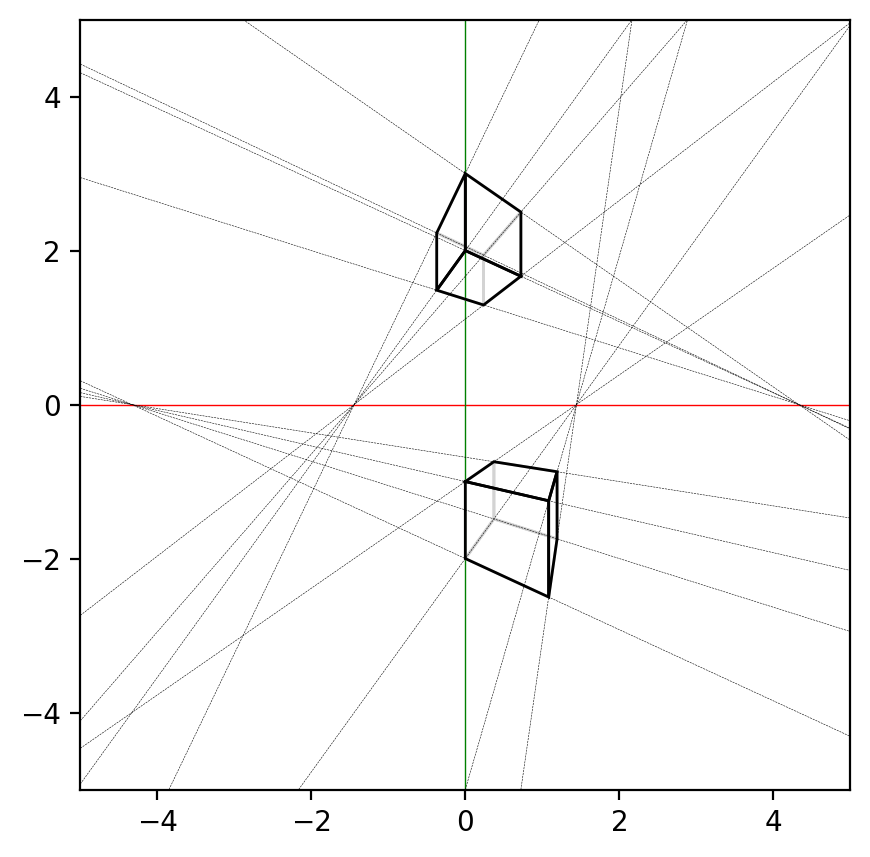

In [8]:
fig01 = plt.figure(num = 1, figsize = (5, 5), dpi = 200)

ax01 = fig01.add_subplot(1, 1, 1)

ax01.set_xlim(left = -5, right = 5)
ax01.set_ylim(bottom = -5, top = 5)

ax01.set_aspect('equal')

ax01.axline(xy1=(0, 0), xy2 = (1, 0), color = 'red', zorder = -15, lw = 0.5)
ax01.axline(xy1=(0, 0), xy2 = (0, 1), color = 'green', zorder = -15, lw = 0.5)

for face in cube.faces:
    ss = signed_square(vertices1, face)
    polygon = Polygon(
        xy = vertices1[face][:, [0, 1]],
        closed = True, 
        fill = False, 
        facecolor = 'gray',
        edgecolor = 'black' if ss > 0 else 'lightgray',
        zorder = 10 if ss > 0 else -10
    )
    ax01.add_patch(polygon)

for (i, j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0, 3), (4, 7), (1, 2), (5, 6)]:
    ax01.axline(
        xy1=vertices1[i][0:2],
        xy2=vertices1[j][0:2],
        ls = '--',
        color = 'black',
        lw=0.2,
        zorder = -10,
)

for face in cube.faces:
    ss = signed_square(vertices2, face)
    polygon = Polygon(
        xy = vertices2[face][:, [0, 1]],
        closed = True, 
        fill = False, 
        facecolor = 'gray',
        edgecolor = 'black' if ss > 0 else 'lightgray',
        zorder = 10 if ss > 0 else -10
    )
    ax01.add_patch(polygon)

for (i, j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0, 3), (4, 7), (1, 2), (5, 6)]:
    ax01.axline(
        xy1=vertices2[i][0:2],
        xy2=vertices2[j][0:2],
        ls = '--',
        color = 'black',
        lw=0.2,
        zorder = -10,
)

In [9]:
def draw_perspective_cube(p, q, r, tx=0, ty=0, tz=0, a=0, b=0):
    
    fig01 = plt.figure(num = 1, figsize = (5, 5), dpi = 200)
    
    ax01 = fig01.add_subplot(1, 1, 1)
    
    ax01.set_xlim(left = -5, right = 5)
    ax01.set_ylim(bottom = -5, top = 5)
    
    ax01.set_aspect('equal')
    
    ax01.axline(xy1=(0, 0), xy2 = (1, 0), color = 'red', zorder = -15, lw = 0.5)
    ax01.axline(xy1=(0, 0), xy2 = (0, 1), color = 'green', zorder = -15, lw = 0.5)

    transformed_vertices = cube.vertices @ translate(-0.5, -0.5, 0).T
    transformed_vertices = transformed_vertices @ rotate_oy(np.deg2rad(a)).T @ rotate_ox(np.deg2rad(b)).T
    transformed_vertices = transformed_vertices @ translate(tx, ty, tz).T @ perspective(p, q, r).T
    normalize_in_place(transformed_vertices)
    print(transformed_vertices)

    for (i, j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0, 3), (4, 7), (1, 2), (5, 6), (4, 5), (7, 6), (3, 2), (0, 1)]:
        ax01.axline(
            xy1=transformed_vertices[i][0:2],
            xy2=transformed_vertices[j][0:2],
            ls = '--',
            color = 'black',
            lw=0.2,
            zorder = -10,
    )
    
    for face in cube.faces:
        ss = signed_square(transformed_vertices, face)
        polygon = Polygon(
            xy = transformed_vertices[face][:, [0, 1]],
            closed = True, 
            fill = False, 
            facecolor = 'gray',
            edgecolor = 'black' if ss > 0 else 'lightgray',
            zorder = 10 if ss > 0 else -10
        )
        ax01.add_patch(polygon)

In [10]:
widgets.interact(
    draw_perspective_cube,
    p = (-0.5, 0.5, 0.01),
    q = (-0.5, 0.5, 0.01),
    r = (-0.5, 0.5, 0.01),
    tx = (-5, 5, 0.5),
    ty = (-5, 5, 0.5),
    tz = (-5, 5, 0.5),
    a = (-90, 90, 1),
    b = (-90, 90, 1)
)

interactive(children=(FloatSlider(value=0.0, description='p', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.draw_perspective_cube(p, q, r, tx=0, ty=0, tz=0, a=0, b=0)>

In [11]:
#2

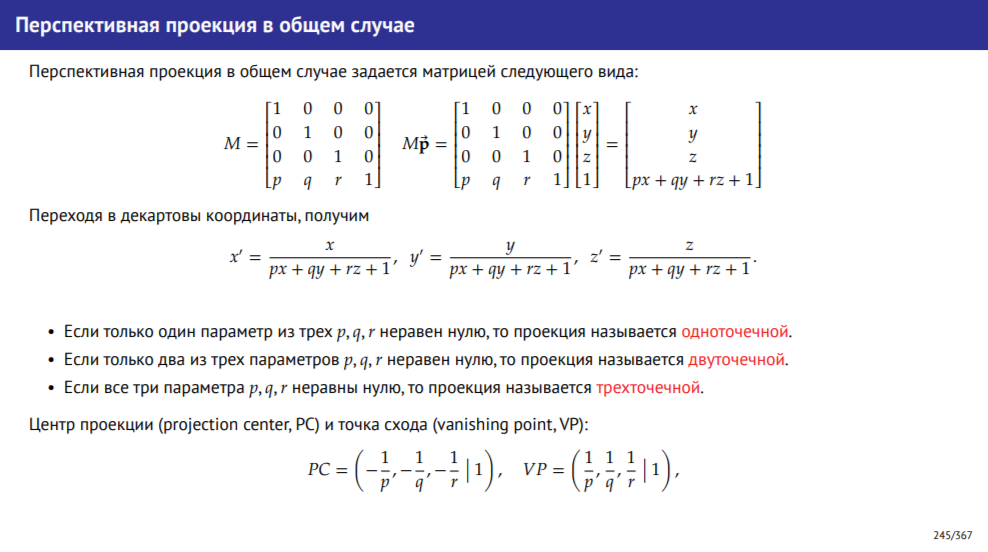

In [12]:
#3

In [13]:
unit_square = Polyhedron(
    vertices = np.array([
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [1, 1, 0, 1],
        [0, 1, 0, 1]
    ]),
    faces = [
        [0, 1, 2, 3]
    ]
)

In [14]:
prbl = np.array([[x, x**2, 0, 1] for x in np.linspace(-5,5,100)])

In [15]:
def draw_perspective_plane(p, q, r):
    fig02 = plt.figure(num = 2, figsize = (5, 5), dpi = 200)
    ax02 = fig02.add_subplot(1, 1, 1)

    ax02.set_xlim(left = -9, right = 9)
    ax02.set_ylim(bottom = -2, top = 8)

    ax02.set_aspect('equal')

    ax02.axline(xy1=(0, 0), xy2 = (8, 0), color = 'red', zorder = 15, lw = 0.5)
    ax02.axline(xy1=(0, 0), xy2 = (0, 8), color = 'green', zorder = 15, lw = 0.5)

    parabl = prbl @ perspective(p, q, r).T
    normalize_in_place(parabl)
    ax02.plot(parabl[:,0], parabl[:,1], lw=0.9)
    
    for i, j in product(range(-8, 8), range(-1, 20)):

        tile_vertices = unit_square.vertices @ translate (i, j, 0).T @ perspective(p, q, r).T
        normalize_in_place(tile_vertices)

        for face in unit_square.faces:
            polygon = Polygon(
                xy = tile_vertices[face][:, [0,1]],
                closed = True,
                fill = False,
                facecolor = 'None', 
                edgecolor = 'black',
            )
            ax02.add_patch(polygon)

In [16]:
widgets.interact(
    draw_perspective_plane, 
    p = (-0.5, 0.5, 0.01),
    q = (-0.5, 0.5, 0.01),
    r = (-0.5, 0.5, 0.01),
)

interactive(children=(FloatSlider(value=0.0, description='p', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.draw_perspective_plane(p, q, r)>